In [1]:
import ale_py
import torch
import gymnasium as gym
import random
from model import DeepQNetwork
from data import ReplayBuffer, Transition

gym.register_envs(ale_py)

In [2]:
num_frames = 4

def make_env(env_id: str):
    env = gym.make(env_id)
    env = gym.wrappers.GrayscaleObservation(env)
    env = gym.wrappers.FrameStackObservation(env, stack_size=num_frames)
    env = gym.wrappers.RecordEpisodeStatistics(env)    
    
    return env

env = make_env("ALE/SpaceInvaders-v5")
obs, info = env.reset()
obs = torch.from_numpy(obs).to(dtype=torch.float32).unsqueeze(0)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [3]:
height = 210
width = 160
action_space = 6

# used to train to predict q-values
predictor_model = DeepQNetwork(
    img_height=210, 
    img_width=160, 
    action_space=6, 
    num_frames=4,
).to('cuda')

# used to provide stable q-values for bellman equation.
target_model =  DeepQNetwork(
    img_height=210, 
    img_width=160, 
    action_space=6, 
    num_frames=4,
).to('cuda')

target_model.load_state_dict(predictor_model.state_dict())
target_model.eval()

Linear Dim 1280
Linear Dim 1280


DeepQNetwork(
  (conv_layers): Sequential(
    (conv2d): Conv2d(4, 8, kernel_size=(8, 8), stride=(2, 2))
    (silu): GELU(approximate='none')
    (conv2d2): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2))
    (silu2): GELU(approximate='none')
    (conv2d3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
    (silu3): GELU(approximate='none')
    (conv2d4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (silu4): GELU(approximate='none')
    (conv2d5): Conv2d(64, 64, kernel_size=(2, 2), stride=(2, 2))
    (silu5): GELU(approximate='none')
  )
  (ff_layers): Sequential(
    (linear1): Linear(in_features=1280, out_features=512, bias=True)
    (gelu): GELU(approximate='none')
    (linear2): Linear(in_features=512, out_features=1280, bias=True)
    (gelu2): GELU(approximate='none')
    (linear3): Linear(in_features=1280, out_features=512, bias=True)
    (gelu3): GELU(approximate='none')
    (action_linear): Linear(in_features=512, out_features=6, bias=True)
  )
)

In [4]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        return predictor_model(state).argmax(dim=1).item()

In [5]:
def train_step(
    replay_buffer: ReplayBuffer, 
    batch_size: int,
    optimizer,
    predictor_model,
    target_model,
    gamma,
    loss_func
) -> float:
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
    
    q_values = predictor_model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    next_q_values = target_model(next_states).max(dim=1).values

    # Bellman equation.
    target = rewards + gamma * next_q_values * (1 - dones)

    loss = loss_func(q_values, target.detach())

    optimizer.zero_grad() # clear grads

    loss.backward() # calc grads.

    optimizer.step() # update model

    return loss.item()

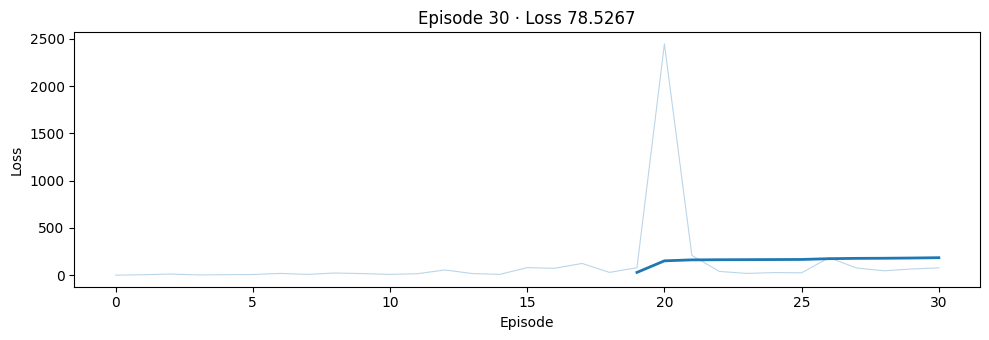

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from matplotlib.ticker import MaxNLocator

BG       = '#0f0f1a'
SURFACE  = '#1a1a2e'
GRID     = '#2a2a3e'
TEXT     = '#e0e0e0'
DIM      = '#888899'
ACCENT   = '#4cc9f0'
ACCENT2  = '#f72585'

# Reset env
episodes = 10000
step_counter = 0
terminated = False
replay_buffer = ReplayBuffer(capacity=10000)

from torch.optim import AdamW

gamma = 0.99
epsilon = 1.0
epsilon_end = 0.01
epsilon_decay = 0.995
batch_size = 64
target_update_freq = 50
learning_rate = 1e-5

optimizer = AdamW(params=predictor_model.parameters(), lr=learning_rate)
loss_func = torch.nn.MSELoss()

fig, ax = plt.subplots(figsize=(11, 4), dpi=100)
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURFACE)
losses = []
smooth_window = 20

for episode in range(episodes):
    state, info = env.reset()
    # states -> ( frames, height, width)
    state = torch.from_numpy(state).to(dtype=torch.float32, device='cuda')
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = select_action(state.unsqueeze(0), epsilon=epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # Prep the observation for the model
        next_state = torch.from_numpy(next_state).to(dtype=torch.float32, device='cuda')
        
        # Push to ReplayBuffer
        replay_buffer.push(Transition(state, action, reward, next_state, terminated))
        
        loss = train_step(
            replay_buffer=replay_buffer, 
            batch_size=batch_size,
            optimizer=optimizer,
            predictor_model=predictor_model,
            target_model=target_model,
            gamma=gamma,
            loss_func=loss_func
        )

        state = next_state
        step_counter += 1

        if step_counter % target_update_freq == 0:
            target_model.load_state_dict(predictor_model.state_dict())
    
    if loss is not None:
        losses.append(loss)

    if episode % 5 == 0 and losses:
        clear_output(wait=True)
        ax.clear()
        ax.set_facecolor(SURFACE)

        x = np.arange(len(losses))
        ax.plot(x, losses, alpha=0.25, color=ACCENT, linewidth=0.7)

        if len(losses) >= smooth_window:
            smoothed = np.convolve(losses, np.ones(smooth_window) / smooth_window, mode='valid')
            sx = np.arange(smooth_window - 1, len(losses))
            ax.plot(sx, smoothed, color=ACCENT, linewidth=2.2, zorder=3)
            ax.fill_between(sx, smoothed, alpha=0.08, color=ACCENT)
            current_smooth = smoothed[-1]
        else:
            current_smooth = losses[-1]

        ax.set_xlabel('Episode', color=DIM, fontsize=10, labelpad=8)
        ax.set_ylabel('Loss', color=DIM, fontsize=10, labelpad=8)
        ax.set_title(
            f'Episode {episode}    ·    loss {losses[-1]:.2f}    ·    avg {current_smooth:.2f}    ·    min {min(losses):.2f}    ·    ε {epsilon:.3f}',
            color=TEXT, fontsize=11, pad=12, fontfamily='monospace'
        )

        ax.tick_params(colors=DIM, labelsize=9)
        ax.grid(True, color=GRID, linewidth=0.5, alpha=0.6)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))

        fig.tight_layout()
        display(fig)

    epsilon = max(epsilon_end, epsilon*epsilon_decay)

    